In [1]:
!pip install xgboost

In [5]:
import pandas as pd
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000.0,16.02,1.0,0.59,Y,3.0
1,21,9600,OWN,5.0,EDUCATION,B,1000.0,11.14,0.0,0.10,N,2.0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500.0,12.87,1.0,0.57,N,3.0
3,23,65500,RENT,4.0,MEDICAL,C,35000.0,15.23,1.0,0.53,N,2.0
4,24,54400,RENT,8.0,MEDICAL,C,35000.0,14.27,1.0,0.55,Y,4.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19083 entries, 0 to 19082
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  19083 non-null  int64  
 1   person_income               19083 non-null  int64  
 2   person_home_ownership       19083 non-null  object 
 3   person_emp_length           18522 non-null  float64
 4   loan_intent                 19083 non-null  object 
 5   loan_grade                  19082 non-null  object 
 6   loan_amnt                   19082 non-null  float64
 7   loan_int_rate               17288 non-null  float64
 8   loan_status                 19082 non-null  float64
 9   loan_percent_income         19082 non-null  float64
 10  cb_person_default_on_file   19082 non-null  object 
 11  cb_person_cred_hist_length  19082 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 1.7+ MB


In [7]:
df = df.dropna()

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [9]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from xgboost import XGBClassifier

model = XGBClassifier()

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [12]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9347048300536672


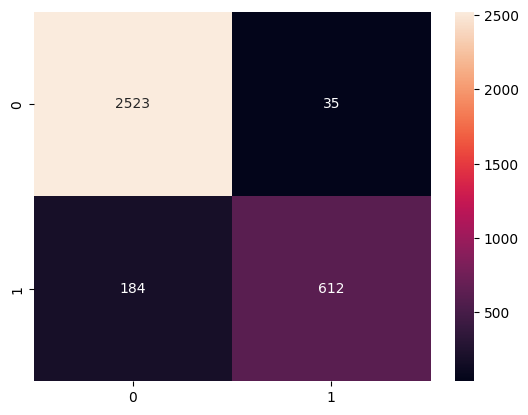

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96      2558
         1.0       0.95      0.77      0.85       796

    accuracy                           0.93      3354
   macro avg       0.94      0.88      0.90      3354
weighted avg       0.94      0.93      0.93      3354

